In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from typing import List, Tuple

In [26]:
def build_grid(L: float, N: int) -> Tuple[np.ndarray, float]:
    """Builds a 1D spatial grid."""
    x = np.linspace(-L, L, N)
    dx = x[1] - x[0]
    return x, dx

def morse_potential(x: np.ndarray, De: float, a: float, xe: float) -> np.ndarray:
    
    return De * ((1 - np.exp(-a * (x - xe)))**2 - 1)

def build_hamiltonian(x: np.ndarray, V: np.ndarray, mass: float = 1.0) -> np.ndarray:
    
    dx = x[1] - x[0]
    N = len(x)
    
    
    T = np.zeros((N, N))
    main_diag = np.ones(N) * (2 / dx**2)
    off_diag = np.ones(N - 1) * (-1 / dx**2)
    T += np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
    T *= (1 / (2 * mass))
   
    U = np.diag(V)
    
    
    H = T + U
    return H

def solve_schrodinger(H: np.ndarray, dx: float) -> Tuple[np.ndarray, np.ndarray]:
  
    energies, wavefunctions_T = eigh(H)
    
    
    wavefunctions = wavefunctions_T.T
    for i in range(len(wavefunctions)):
        norm = np.sum(np.abs(wavefunctions[i, :]**2)) * dx
        wavefunctions[i, :] /= np.sqrt(norm)
        
    return energies, wavefunctions

In [27]:
def compute_matrice(wavefunctions: np.ndarray, x: np.ndarray, dx: float) -> Tuple[np.ndarray, np.ndarray]:
   
    n = wavefunctions.shape[0]
    x_matrice = np.zeros((n, n), dtype=float)
    p_matrice = np.zeros((n, n), dtype=complex)
    
    d_wavefunctions = np.gradient(wavefunctions, dx, axis=1)
    
    for i in range(n):
        for j in range(n):
            x_matrice[i, j] = np.sum(wavefunctions[i, :] * x * wavefunctions[j, :]) * dx
            p_matrice[i, j] = (-1j) * np.sum(wavefunctions[i, :] * d_wavefunctions[j, :]) * dx
            
    return np.real_if_close(x_matrice), p_matrice

def microcanonical_OTOC(Energy: np.ndarray, x_matrice: np.ndarray, p_matrice: np.ndarray, n_index: int, t_array: np.ndarray) -> np.ndarray:
   
    Cvalues = np.zeros_like(t_array, dtype=float)
    deltaE = Energy[:, None] - Energy[None, :]
    
    for k, t in enumerate(t_array):
        phases = np.exp(1j * deltaE * t)
        x_t = x_matrice * phases
        commutator = (x_t @ p_matrice) - (p_matrice @ x_t)
        commutator_sq = commutator @ commutator
        Cvalues[k] = -np.real(commutator_sq[n_index, n_index])
        
    return Cvalues

def thermal_OTOC(Energy: np.ndarray, x_matrice: np.ndarray, p_matrice: np.ndarray, beta: float, t_array: np.ndarray) -> np.ndarray:
    
    weights = np.exp(-beta * Energy)
    Z = np.sum(weights)
    Csum = np.zeros_like(t_array, dtype=float)
    
    for n_index in range(len(Energy)):
        C_n = microcanonical_OTOC(Energy, x_matrice, p_matrice, n_index, t_array)
        Csum += weights[n_index] * C_n
        
    return Csum / Z

In [28]:
def adaptive_downsample(x, y, max_points=2000):
    if len(x) > max_points:
        step = len(x) // max_points
        return x[::step], y[::step]
    return x, y

def add_text_label_to_line(ax, x, y, text, x_pos_ratio=0.5, color='black'):
  
    if len(x) == 0 or len(y) == 0: return
    idx = int(len(x) * x_pos_ratio)
    ax.text(x[idx], y[idx], text, color=color, fontsize=12,
            ha='center', va='bottom',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

def plot_time_series(t, C, label_text="", title="", color=None, ax=None, ylabel=""):
   
    positive_indices = np.where(C > 0)[0]
    if len(positive_indices) == 0:
        print(f"Warning: No positive data for label '{label_text}'. Skipping.")
        return ax

    t_plot, C_plot = adaptive_downsample(t[positive_indices], C[positive_indices])

    create_new_figure = ax is None
    if create_new_figure:
        fig, ax = plt.subplots(figsize=(12, 6))
    else:
        fig = ax.figure

    n_val = None
    if "n =" in label_text:
        try: n_val = int(label_text.split('=')[-1].strip())
        except (ValueError, IndexError): pass

    colors = {0: '#8A2BE2', 5: '#228B22', 10: '#1E90FF', 20: '#FFD700', 30: '#FF6347', 40: '#4682B4'}
    plot_color = color or colors.get(n_val, 'gray')
    ax.plot(t_plot, C_plot, linewidth=2, color=plot_color, alpha=0.9)

    if label_text and n_val is not None:
        x_pos_map = {0: 0.5, 5: 0.25, 10: 0.45, 20: 0.18, 30: 0.35, 40: 0.1}
        x_pos = x_pos_map.get(n_val, 0.1)
        add_text_label_to_line(ax, t_plot, C_plot, label_text, x_pos_ratio=x_pos, color=plot_color)

    if create_new_figure or ax.get_ylabel() == '':
        ax.set_ylabel(ylabel if ylabel else r"$C_n(t)$", fontsize=14)

    ax.set_yscale("log")
    ax.set_xlabel("t", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(False)

    if create_new_figure:
        ax.set_title(title, fontsize=16)
        fig.tight_layout()
        plt.show()

    return ax

In [29]:
def compute_and_plot_vdw_otocs(
    De: float, a: float, xe: float, mass: float,
    L: float, N: int, num_states_basis: int, states_to_plot: list,
    tmax: float, nt: int, betas: list
):
   
    print("--- Starting Simulation for van der Waals Potential ---")

 
    x, dx = build_grid(L, N)
    V = morse_potential(x, De, a, xe)
    print("Building Hamiltonian...")
    H = build_hamiltonian(x, V, mass)
    print("Solving Schrödinger equation (this may take a moment)...")
    energies, wavefunctions = solve_schrodinger(H, dx)
    
 
    bound_indices = np.where(energies < 0)[0]
    bound_energies = energies[bound_indices]
    bound_wavefunctions = wavefunctions[bound_indices]
    num_found_bound_states = len(bound_energies)

    if num_found_bound_states == 0:
        print("Error: No bound states found for the given potential parameters. Exiting.")
        return None
        
    print(f"Found {num_found_bound_states} bound states.")

  
    actual_basis_size = min(num_states_basis, num_found_bound_states)
    print(f"Using the lowest {actual_basis_size} states for the calculation basis.")
    E_basis = bound_energies[:actual_basis_size]
    psi_basis = bound_wavefunctions[:actual_basis_size]

  
    valid_states_to_plot = [n for n in states_to_plot if n < actual_basis_size]
    if not valid_states_to_plot:
        print("Warning: None of the requested states to plot exist in the found bound states.")
       
        if actual_basis_size > 0:
            valid_states_to_plot = [0]
        else: 
             return None
    print(f"Will plot OTOC for existing states: {valid_states_to_plot}")

    x_mat, p_mat = compute_matrice(psi_basis, x, dx)
    t = np.linspace(0, tmax, nt)


    fig_combined, ax_combined = plt.subplots(figsize=(12, 6))
    all_positive_c_values = []

    print("Calculating Microcanonical OTOCs...")
    for n_index in valid_states_to_plot: 
        C_n = microcanonical_OTOC(E_basis, x_mat, p_mat, n_index, t)
        positive_vals = C_n[C_n > 0]
        if len(positive_vals) > 0:
            all_positive_c_values.extend(positive_vals)
        plot_time_series(t, C_n, label_text=f"n = {n_index}", ax=ax_combined)

    if all_positive_c_values:
        min_y, max_y = np.min(all_positive_c_values), np.max(all_positive_c_values)
        ax_combined.set_ylim(min_y * 0.9, max_y * 1.1)

    ax_combined.set_title(f"Microcanonical OTOC for Morse Potential (De={De})", fontsize=16)
    fig_combined.tight_layout()
    plt.show()


    print("Calculating Thermal OTOCs...")
    for beta in betas:
        C_T = thermal_OTOC(E_basis, x_mat, p_mat, beta, t)
        plot_time_series(t, C_T, ylabel="$C_T(t)$",
                         title=f"Thermal OTOC ($\\beta={beta}$)",
                         color='darkblue')
    
    print("--- Simulation Complete ---")
    return {"energies": E_basis, "wavefunctions": psi_basis}

--- Starting Simulation for van der Waals Potential ---
Building Hamiltonian...
Solving Schrödinger equation (this may take a moment)...
Found 30 bound states.
Using the lowest 30 states for the calculation basis.
Will plot OTOC for existing states: [0, 5, 10, 20]
Calculating Microcanonical OTOCs...


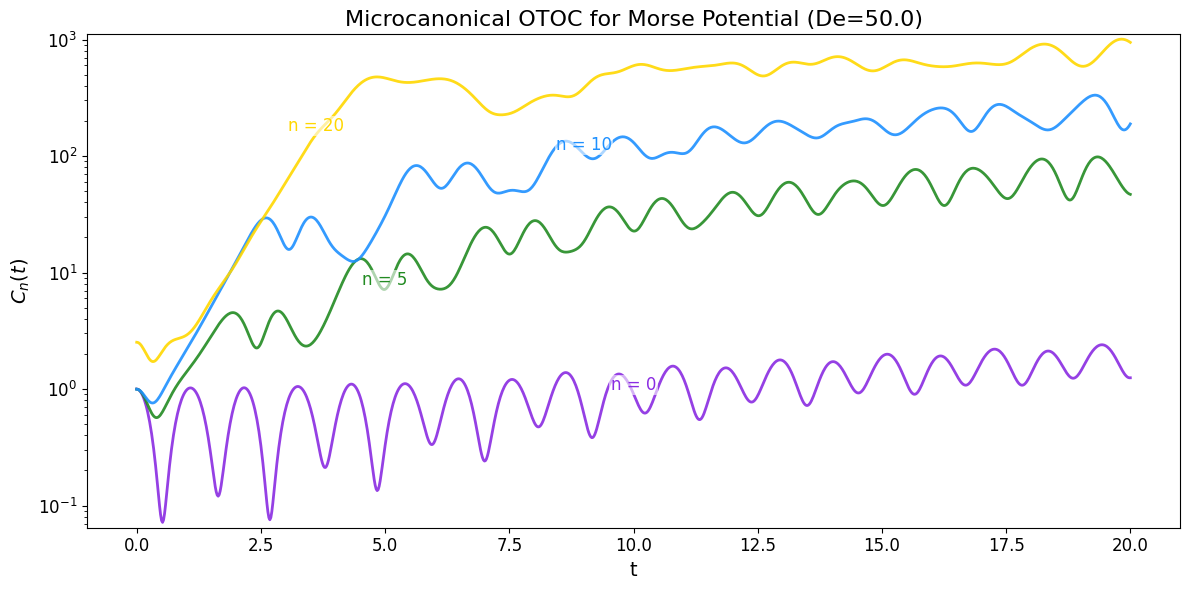

Calculating Thermal OTOCs...


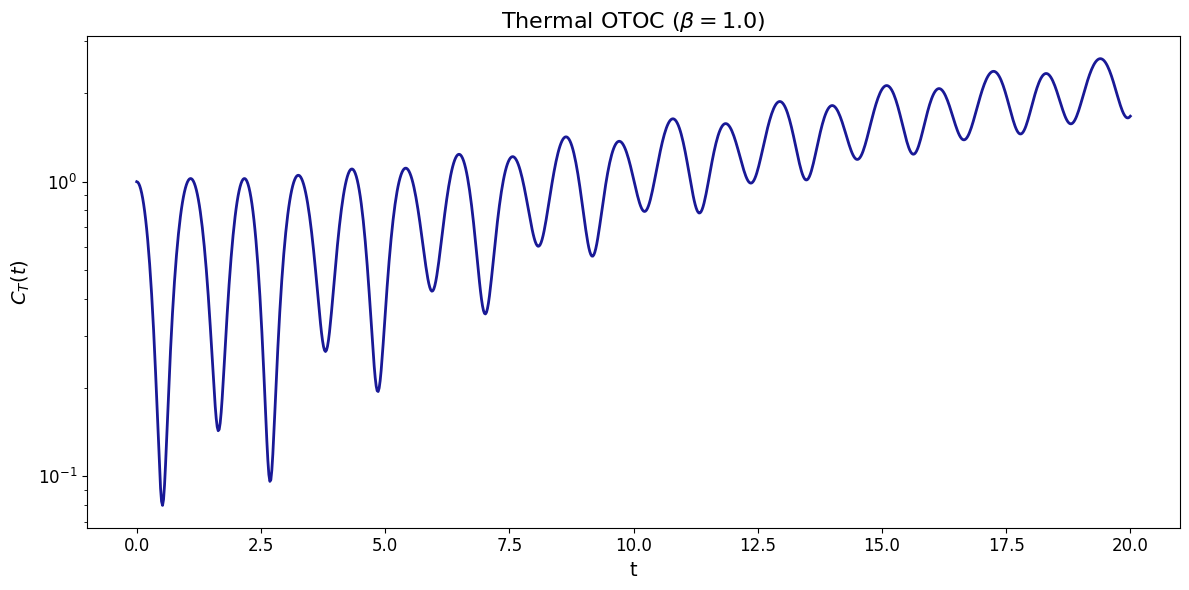

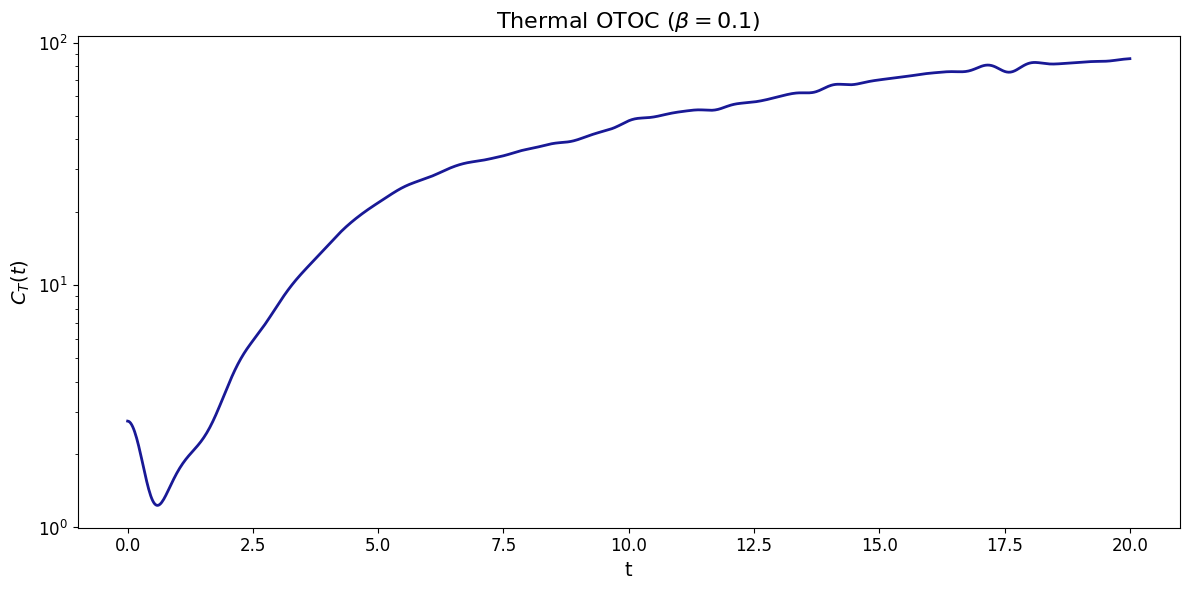

--- Simulation Complete ---


In [30]:
# --- 1. Define Simulation Parameters ---

# Potential Parameters (approximating a diatomic molecule)
De = 50.0   # Depth of the potential well
a = 0.3     # Width of the potential well
xe = 0.0    # Equilibrium position (center of the well)
mass = 1.0  # Mass of the particle

# Grid and Basis Parameters
L_box = 15.0      # Grid extends from -L to L
N_points = 2001   # Number of grid points (higher is more accurate but slower)
num_states_basis = 50 # Number of low-energy states to use in our calculation basis

# OTOC Parameters
states_to_plot = [0, 5, 10, 20, 30, 40] # Which energy levels 'n' to plot (n=0 is ground state)
time_max = 20.0
time_steps = 1001
beta_values = [1.0, 0.1]

# --- 2. Run the Simulation ---
results = compute_and_plot_vdw_otocs(
    De=De, a=a, xe=xe, mass=mass,
    L=L_box, N=N_points, num_states_basis=num_states_basis,
    states_to_plot=states_to_plot,
    tmax=time_max, nt=time_steps, betas=beta_values
)